# Logistic Regression

## Learning Objectives
- Understand why logistic regression uses $\sigma(\theta^T x)$ instead of $\theta^T x$ directly, and what problem it solves
- Understand that logistic regression is **parametric** and **discriminative** — it models $P(y=1 \mid x;\theta)$ directly without modelling $P(x)$
- Derive the log-likelihood $\ell(\theta) = y^T \log \sigma(X\theta) + (1-y)^T \log(1-\sigma(X\theta))$ from first principles
- Derive the gradient $\nabla\ell(\theta) = X^T(y - \sigma(X\theta))$ using the chain rule and the identity $\sigma'(z)=\sigma(z)(1-\sigma(z))$
- Implement `fit`, `predict_proba`, and `predict` in NumPy using batch gradient ascent

## Problem Statement

Given a training set $\{(x^{(i)}, y^{(i)})\}_{i=1}^{n}$ where $x^{(i)} \in \mathbb{R}^{d}$ and $y^{(i)} \in \{0,1\}$, find parameters $\theta$ that maximise the conditional log-likelihood:

$\displaystyle \theta^* = \arg\max_{\theta}\; \ell(\theta) = \arg\max_{\theta} \sum_{i=1}^{n} \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right]$

---

### Why Not Linear Regression?

Linear regression fits $\hat{y} = \theta^T x$ for continuous targets. Applied to binary classification:
- Predictions can exceed 1 or fall below 0 — not valid probabilities
- The MSE loss has no principled probabilistic interpretation for Bernoulli outcomes

Logistic regression fixes this by passing the linear score through the **sigmoid function**, squashing it to $(0,1)$.

---

### Core Idea

Model the probability of the positive class directly:

$\displaystyle h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}} \in (0, 1)$

Train by maximising the Bernoulli log-likelihood (equivalently, minimising binary cross-entropy).

| Property | Linear Regression | Logistic Regression |
|---|---|---|
| Output | $\hat{y} \in \mathbb{R}$ (unbounded) | $h_\theta(x) \in (0,1)$ (probability) |
| Task | Regression | Binary Classification |
| Objective | Minimise MSE | Maximise log-likelihood |
| Training | Normal Equation / Gradient Descent | Batch Gradient Ascent |
| Decision rule | — | $\hat{y} = 1$ if $\theta^T x \geq 0$ |
| Closed-form | Yes $(X^T X)^{-1} X^T y$ | No (iterative only) |

---

### Decision Boundary

The boundary between the two classes is the hyperplane $\{x : \theta^T x = 0\}$:

$\displaystyle \hat{y} = \begin{cases} 1 & \text{if } \theta^T x \geq 0 \\ 0 & \text{if } \theta^T x < 0 \end{cases}$

Logistic regression is therefore always a **linear classifier** — its capacity is controlled by regularisation, not a bandwidth parameter.

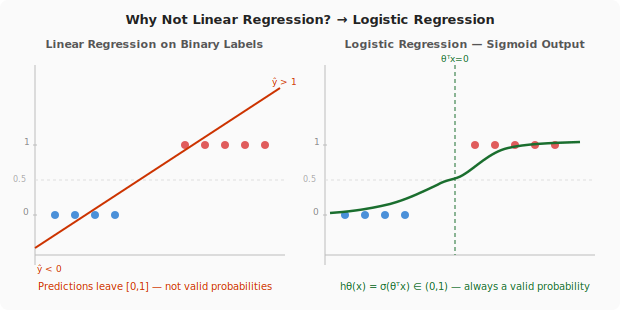

In [1]:
from IPython.display import SVG, display

svg = """
<svg xmlns="http://www.w3.org/2000/svg" width="620" height="310" viewBox="0 0 620 310">
  <rect width="620" height="310" fill="#fafafa" rx="8"/>
  <text x="310" y="24" text-anchor="middle" font-size="13" font-weight="bold" fill="#222">Why Not Linear Regression? &#x2192; Logistic Regression</text>

  <!-- LEFT PANEL: Linear regression on binary labels -->
  <text x="155" y="48" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Linear Regression on Binary Labels</text>
  <line x1="35" y1="255" x2="285" y2="255" stroke="#bbb" stroke-width="1"/>
  <line x1="35" y1="65"  x2="35"  y2="265" stroke="#bbb" stroke-width="1"/>
  <text x="29" y="145" text-anchor="end" font-size="9" fill="#888">1</text>
  <text x="29" y="215" text-anchor="end" font-size="9" fill="#888">0</text>
  <line x1="33" y1="145" x2="37" y2="145" stroke="#bbb" stroke-width="1"/>
  <line x1="33" y1="215" x2="37" y2="215" stroke="#bbb" stroke-width="1"/>
  <line x1="35" y1="180" x2="285" y2="180" stroke="#ddd" stroke-width="1" stroke-dasharray="3,3"/>
  <text x="26" y="182" text-anchor="end" font-size="8" fill="#aaa">0.5</text>

  <circle cx="55"  cy="215" r="4" fill="#4a90d9"/>
  <circle cx="75"  cy="215" r="4" fill="#4a90d9"/>
  <circle cx="95"  cy="215" r="4" fill="#4a90d9"/>
  <circle cx="115" cy="215" r="4" fill="#4a90d9"/>
  <circle cx="185" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="205" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="225" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="245" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="265" cy="145" r="4" fill="#e05c5c"/>

  <line x1="35" y1="248" x2="280" y2="88" stroke="#cc3300" stroke-width="2"/>
  <text x="272" y="85"  font-size="9" fill="#cc3300">y&#x302; &gt; 1</text>
  <text x="37"  y="272" font-size="9" fill="#cc3300">y&#x302; &lt; 0</text>
  <text x="155" y="290" text-anchor="middle" font-size="10" fill="#cc3300">Predictions leave [0,1] &#x2014; not valid probabilities</text>

  <!-- RIGHT PANEL: Logistic regression -->
  <text x="465" y="48" text-anchor="middle" font-size="11" font-weight="bold" fill="#555">Logistic Regression &#x2014; Sigmoid Output</text>
  <line x1="325" y1="255" x2="595" y2="255" stroke="#bbb" stroke-width="1"/>
  <line x1="325" y1="65"  x2="325" y2="265" stroke="#bbb" stroke-width="1"/>
  <text x="319" y="145" text-anchor="end" font-size="9" fill="#888">1</text>
  <text x="319" y="215" text-anchor="end" font-size="9" fill="#888">0</text>
  <line x1="323" y1="145" x2="327" y2="145" stroke="#bbb" stroke-width="1"/>
  <line x1="323" y1="215" x2="327" y2="215" stroke="#bbb" stroke-width="1"/>
  <line x1="325" y1="180" x2="595" y2="180" stroke="#ddd" stroke-width="1" stroke-dasharray="3,3"/>
  <text x="316" y="182" text-anchor="end" font-size="8" fill="#aaa">0.5</text>

  <circle cx="345" cy="215" r="4" fill="#4a90d9"/>
  <circle cx="365" cy="215" r="4" fill="#4a90d9"/>
  <circle cx="385" cy="215" r="4" fill="#4a90d9"/>
  <circle cx="405" cy="215" r="4" fill="#4a90d9"/>
  <circle cx="475" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="495" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="515" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="535" cy="145" r="4" fill="#e05c5c"/>
  <circle cx="555" cy="145" r="4" fill="#e05c5c"/>

  <line x1="455" y1="65" x2="455" y2="255" stroke="#1a6e2e" stroke-width="1" stroke-dasharray="4,3"/>
  <text x="455" y="62" text-anchor="middle" font-size="9" fill="#1a6e2e">&#x3B8;&#x1D40;x=0</text>

  <path d="M 330,213 C 345,212 365,210 390,204 C 408,199 422,192 437,185
           C 447,179 455,180 463,175 C 475,168 490,152 508,148
           C 525,144 548,143 580,142"
        fill="none" stroke="#1a6e2e" stroke-width="2.5"/>

  <text x="465" y="290" text-anchor="middle" font-size="10" fill="#1a6e2e">h&#x3B8;(x) = &#x3C3;(&#x3B8;&#x1D40;x) &#x2208; (0,1) &#x2014; always a valid probability</text>
</svg>
"""

display(SVG(svg))

## Hypothesis Function

For a query point $x \in \mathbb{R}^{d+1}$ (with $x_0 = 1$ prepended), logistic regression predicts:

$\displaystyle \hat{y} = \mathbf{1}\!\left[h_\theta(x) \geq 0.5\right], \qquad h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$

where $\sigma$ is the **sigmoid (logistic) function** with key properties:

| Property | Value |
|---|---|
| $\sigma(0)$ | $0.5$ — neutral score → 50 % probability |
| $\sigma(z) \to 1$ as $z \to +\infty$ | high score → confident positive |
| $\sigma(z) \to 0$ as $z \to -\infty$ | low score → confident negative |
| $\sigma'(z) = \sigma(z)(1-\sigma(z))$ | used in gradient derivation |
| $1-\sigma(z) = \sigma(-z)$ | symmetry property |

The probability of each class under the model:

$\displaystyle P(y=1 \mid x;\theta) = h_\theta(x) = \sigma(\theta^T x)$

$\displaystyle P(y=0 \mid x;\theta) = 1 - h_\theta(x) = \sigma(-\theta^T x)$

Combining both into a single expression (**Bernoulli likelihood**):

$\displaystyle P(y \mid x;\theta) = h_\theta(x)^{y} \cdot (1-h_\theta(x))^{1-y}$

**Key difference from linear regression**: $\theta^T x$ is unbounded, but $\sigma(\theta^T x) \in (0,1)$ is always a valid probability. The decision boundary — where $h_\theta(x) = 0.5$ — is the hyperplane $\theta^T x = 0$.

## Derivation

**High-level steps:**
1. Model each label as Bernoulli: $P(y \mid x;\theta) = h_\theta(x)^y \cdot (1-h_\theta(x))^{1-y}$
2. Write the log-likelihood over all training examples
3. Differentiate with respect to $\theta_j$
4. Simplify using $\sigma'(z) = \sigma(z)(1-\sigma(z))$

---

**Step 1 — Bernoulli model**

$\displaystyle P(y^{(i)} \mid x^{(i)};\theta) = h_\theta(x^{(i)})^{y^{(i)}} \cdot (1-h_\theta(x^{(i)}))^{1-y^{(i)}}$

When $y^{(i)}=1$: reduces to $h_\theta(x^{(i)})$. When $y^{(i)}=0$: reduces to $1-h_\theta(x^{(i)})$.

---

**Step 2 — Log-likelihood**

Assuming i.i.d. examples, the log-likelihood factorises:

$\displaystyle \ell(\theta) = \sum_{i=1}^{n} \left[ y^{(i)} \log h_\theta(x^{(i)}) + (1-y^{(i)}) \log(1-h_\theta(x^{(i)})) \right]$

In matrix form: $\quad \ell(\theta) = y^T \log \sigma(X\theta) + (1-y)^T \log(1-\sigma(X\theta))$

---

**Step 3 — Gradient with respect to $\theta_j$**

$\displaystyle \frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^{n} \left[ \frac{y^{(i)}}{h_\theta(x^{(i)})} - \frac{1-y^{(i)}}{1-h_\theta(x^{(i)})} \right] \cdot \frac{\partial h_\theta}{\partial \theta_j}$

Using $\dfrac{\partial h}{\partial \theta_j} = h(1-h) \cdot x_j^{(i)}$ (chain rule + sigmoid derivative):

$\displaystyle \frac{\partial \ell}{\partial \theta_j} = \sum_{i=1}^{n} \left(y^{(i)} - h_\theta(x^{(i)})\right) x_j^{(i)}$

---

**Step 4 — Matrix form**

Stacking over all $j$:

$\displaystyle \boxed{\nabla_\theta \ell(\theta) = X^T \bigl(y - \sigma(X\theta)\bigr) = X^T(y - h)}$

**Interpretation**: The gradient is the feature-weighted sum of residuals $(y^{(i)} - h_\theta(x^{(i)}))$. When the model fits well, $h_\theta(x^{(i)}) \approx y^{(i)}$, residuals ≈ 0, and the gradient ≈ 0 (converged).

## Training Algorithm

Logistic regression has no closed-form solution (unlike linear regression). We use **batch gradient ascent** to maximise $\ell(\theta)$.

**Step 1 — Initialise**

Set $\theta \leftarrow \mathbf{0} \in \mathbb{R}^{d+1}$. Prepend a bias column of ones to $X$, giving $X \in \mathbb{R}^{n \times (d+1)}$.

**Step 2 — Compute predictions**

$\displaystyle h = \sigma(X\theta) \in \mathbb{R}^n$

**Step 3 — Compute the gradient**

$\displaystyle \nabla \ell(\theta) = X^T(y - h) \in \mathbb{R}^{d+1}$

**Step 4 — Gradient ascent step**

$\displaystyle \theta \leftarrow \theta + \frac{\alpha}{n}\, X^T(y - h)$

**Step 5 — Repeat** steps 2–4 until $\|\nabla \ell\| < \varepsilon$ or maximum iterations reached.

**Complexity**: $O(nd)$ per iteration (matrix–vector products). Convergence is guaranteed because the log-likelihood is **strictly concave** in $\theta$.

| Quantity | Formula | Shape |
|----------|---------|-------|
| Predictions | $h = \sigma(X\theta)$ | $(n)$ |
| Residuals | $r = y - h$ | $(n)$ |
| Gradient | $g = X^T r \;/\; n$ | $(d+1)$ |
| Update | $\theta \leftarrow \theta + \alpha\, g$ | $(d+1)$ |

## Key Properties

**Parametric** — logistic regression learns a fixed-size parameter vector $\theta \in \mathbb{R}^{d+1}$. Prediction cost at test time is $O(d)$, independent of training set size.

**Discriminative** — models $P(y=1 \mid x;\theta)$ directly. Does not model $P(x)$ or $P(x \mid y)$ (contrast with Naive Bayes, GDA).

**Log-likelihood is strictly concave** — the Hessian $\nabla^2 \ell = -X^T W X$ where $W = \text{diag}(h_i(1-h_i))$ is always negative semi-definite, so gradient ascent converges to the **global maximum** (if it exists; no maximum exists when classes are perfectly linearly separable without regularisation).

**Decision boundary is a hyperplane** — the boundary $\{x : \theta^T x = 0\}$ is always linear. Logistic regression is therefore a **linear classifier**.

**Relation to cross-entropy loss** — minimising $J_{CE}(\theta) = -\tfrac{1}{n}\ell(\theta)$ (the convention used in deep learning) is identical to maximising $\ell(\theta)$. The gradient is $-\tfrac{1}{n}X^T(y - h)$.

**Connection to GLMs** — logistic regression is a Generalised Linear Model with a Bernoulli response family and logit link function. The gradient $X^T(y - h)$ has the same canonical form as linear regression (with the appropriate mean function $h$).

**No closed-form solution** — unlike the Normal Equation for linear regression, the MLE for logistic regression requires iterative optimisation (gradient ascent, Newton's method, L-BFGS, etc.).

In [2]:
import numpy as np


def sigmoid(z):
    """
    Numerically stable sigmoid function.

    Input
    -----
    z : float or np.ndarray  — linear scores θᵀx (any shape)

    Output
    ------
    σ(z) : same shape as z, values in (0, 1)
    """
    return np.where(z >= 0,
                    1.0 / (1.0 + np.exp(-z)),
                    np.exp(z) / (1.0 + np.exp(z)))


def fit(X, y, alpha=0.1, max_iter=1000, tol=1e-6):
    """
    Train logistic regression via batch gradient ascent on the log-likelihood.

    Inputs
    ------
    X        : np.ndarray, shape (n, d+1)  — design matrix with bias column (x_0=1) prepended
    y        : np.ndarray, shape (n,)      — binary labels {0, 1}
    alpha    : float                       — learning rate (step size for gradient ascent)
    max_iter : int                         — maximum number of gradient ascent iterations
    tol      : float                       — stop when ||∇ℓ / n|| < tol

    Outputs
    -------
    theta   : np.ndarray, shape (d+1,)   — learned parameters (bias first)
    history : list of (int, float)       — (iteration, log-likelihood) at each step
    """
    n, d = X.shape
    theta = np.zeros(d)
    history = []

    for t in range(max_iter):
        h    = sigmoid(X @ theta)                      # (n,)  predicted probabilities
        grad = X.T @ (y - h) / n                       # (d+1,) gradient of avg log-likelihood
        theta = theta + alpha * grad                   # gradient ascent step

        h_clip = np.clip(h, 1e-12, 1 - 1e-12)
        ll = np.sum(y * np.log(h_clip) + (1 - y) * np.log(1 - h_clip))
        history.append((t, ll))

        if np.linalg.norm(grad) < tol:
            break

    return theta, history


def predict_proba(X, theta):
    """
    Compute the probability of the positive class P(y=1 | x; theta).

    Inputs
    ------
    X     : np.ndarray, shape (n, d+1)  — design matrix with bias column (x_0=1) prepended
    theta : np.ndarray, shape (d+1,)    — model parameters

    Output
    ------
    proba : np.ndarray, shape (n,)  — P(y=1 | x; theta) for each example
    """
    return sigmoid(X @ theta)


def predict(X, theta, threshold=0.5):
    """
    Return binary class predictions.

    Inputs
    ------
    X         : np.ndarray, shape (n, d+1)  — design matrix with bias column (x_0=1) prepended
    theta     : np.ndarray, shape (d+1,)    — model parameters
    threshold : float                       — decision threshold (default 0.5)

    Output
    ------
    y_hat : np.ndarray, shape (n,)  — predicted labels {0, 1}
    """
    return (predict_proba(X, theta) >= threshold).astype(int)